In [1]:
import numpy as np
import healpy as hp
import pysm3 as sm

import matplotlib as mpl
import matplotlib.pyplot as plt

import cmasher as cmr
import seaborn as sns

import sys
sys.path.append('../')

from src.utils import pretty_axes, modify_rc, w_object, patch_creation
modify_rc()
modify_rc()
from src import synthesize


In [ ]:
NSIDE = 512
LMAX = 3*NSIDE - 1

ells = np.arange(LMAX+1)

sky6 = sm.Sky(nside=NSIDE, preset_strings=['s6'])

/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/fitsfunc.py:683: ComplexWarning: Casting complex values to real discards the imaginary part
  alm.real[i] = almr
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/fitsfunc.py:684: ComplexWarning: Casting complex values to real discards the imaginary part
  alm.imag[i] = almi
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/fitsfunc.py:683: ComplexWarning: Casting complex values to real discards the imaginary part
  alm.real[i] = almr
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/fitsfunc.py:684: ComplexWarning: Casting complex values to real discards the imaginary part
  alm.imag[i] = almi


generating monofractal field


/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/sphtfunc.py:1407: ComplexWarning: Casting complex values to real discards the imaginary part
  (np.asarray(cl, dtype=np.float64) if cl is not None else None)
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/sphtfunc.py:1363: ComplexWarning: Casting complex values to real discards the imaginary part
  cls_list = [np.asarray(cls, dtype=np.float64)]


In [3]:
t0, e0, b0 = hp.alm2map(sky6.components[0].template_largescale_alm.value, NSIDE, pol=False)
cls0 = hp.anafast([t0, e0, b0], lmax=LMAX, pol=False)
cl_t0, cl_e0, cl_b0, cl_te0 = cls0[0], cls0[1], cls0[2], cls0[3]

Text(0.5, 1.0, '$b_0$')

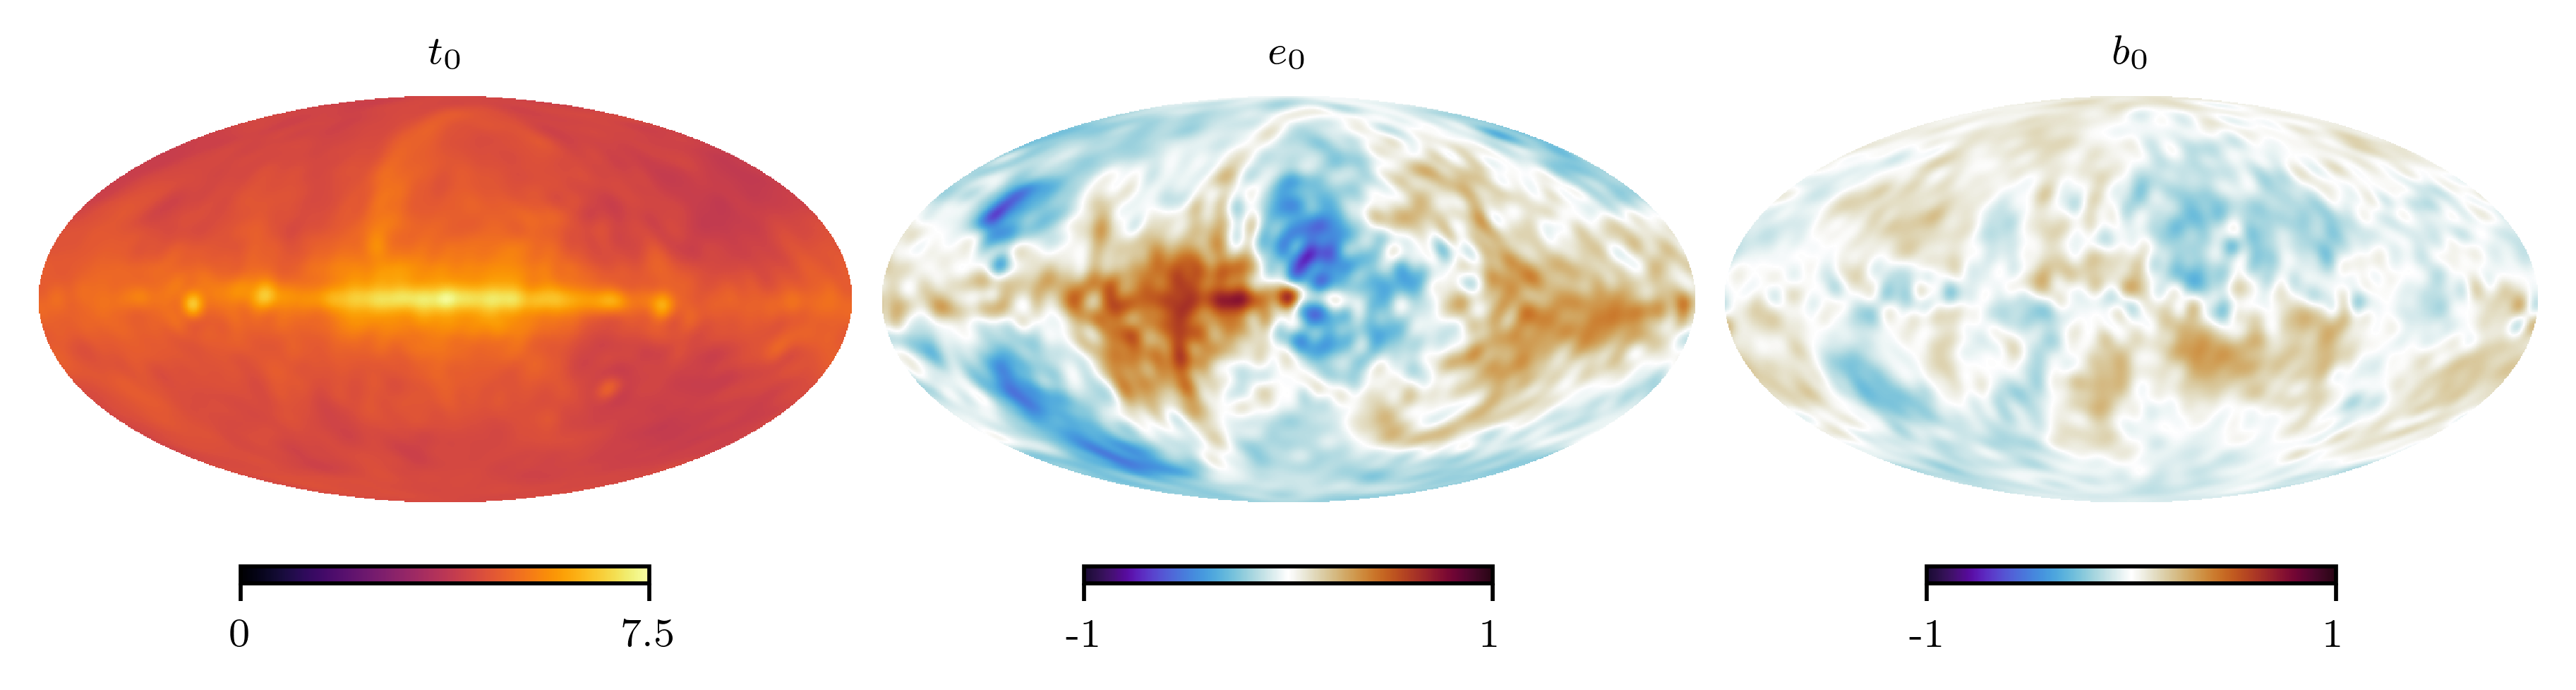

In [4]:
fig = plt.figure(figsize=(7., 3.5), dpi=512)

fusion_cmap = cmr.fusion_r
fusion_cmap.set_under('w')

cmapI = sns.color_palette('inferno', as_cmap=True)
cmapI.set_under('w')

mod_mapI = hp.alm2map(sky6.components[0].modulate_alm[0].value, NSIDE)
mod_mapP = hp.alm2map(sky6.components[0].modulate_alm[1].value, NSIDE)

hp.mollview(t0, cmap=cmapI, min=0., max=7.5, fig=fig, sub=(1, 3, 1), title='')
ax = plt.gca()
ax.set_title(r'$t_0$', fontsize=8.)
hp.mollview(e0, cmap=fusion_cmap, min=-1., max=1., fig=fig, sub=(1, 3, 2), title='')
ax = plt.gca()
ax.set_title(r'$e_0$', fontsize=8.)
hp.mollview(b0, cmap=fusion_cmap, min=-1., max=1., fig=fig, sub=(1, 3, 3), title='')
ax = plt.gca()
ax.set_title(r'$b_0$', fontsize=8.)


In [5]:

cl_tt = sky6.components[0].small_scale_cl[0][:LMAX+1].value
cl_tt[cl_tt == 0.] = 1e-15
cl_ee = sky6.components[0].small_scale_cl[1][:LMAX+1].value
cl_ee[cl_ee == 0.] = 1e-15
cl_bb = sky6.components[0].small_scale_cl[2][:LMAX+1].value
cl_bb[cl_bb == 0.] = 1e-15
cl_te = sky6.components[0].small_scale_cl[3][:LMAX+1].value
cl_te[cl_te == 0.] = 1e-15

cl_tt = np.float64(cl_tt)
cl_ee = np.float64(cl_ee)
cl_bb = np.float64(cl_bb)
cl_te = np.float64(cl_te)

C_VAL = 5.0
LAMBDA_VAL = 0.25
LARGE_C = 1.0

t_delta_params = ({
    'cl_target': cl_tt,
    'cl_noise': cl_tt,
    'c':C_VAL,
    'lambda':LAMBDA_VAL,
    'anisotropy':'isotropic',
    'large_alm':sky6.components[0].template_largescale_alm.value[0],
    'large_c_param': LARGE_C,
    'mod_map': mod_mapI,
},{
    'cl_target': cl_tt,
    'cl_noise': cl_tt,
    'c':C_VAL,
    'lambda':LAMBDA_VAL,
    'anisotropy':'meridional',
    'large_alm':sky6.components[0].template_largescale_alm.value[0],
    'large_c_param': LARGE_C,
    'mod_map': mod_mapI,
})
e_delta_params = ({
    'cl_target': cl_ee,
    'cl_noise':cl_ee,
    'c':C_VAL,
    'lambda':LAMBDA_VAL,
    'anisotropy':'isotropic',
    'large_alm':sky6.components[0].template_largescale_alm.value[1],
    'large_c_param': LARGE_C,
    'mod_map': mod_mapP,
},{
    'cl_target': cl_ee,
    'cl_noise':cl_ee,
    'c':C_VAL,
    'lambda':LAMBDA_VAL,
    'anisotropy':'meridional',
    'large_alm':sky6.components[0].template_largescale_alm.value[1],
    'large_c_param': LARGE_C,
    'mod_map': mod_mapP,
})
b_delta_params = ({
    'cl_target':cl_bb,
    'cl_noise':cl_bb,
    'c':C_VAL,
    'lambda':LAMBDA_VAL,
    'anisotropy':'isotropic',
    'large_alm':sky6.components[0].template_largescale_alm.value[2],
    'large_c_param': LARGE_C,
    'mod_map': mod_mapP,
},{
    'cl_target':cl_bb,
    'cl_noise':cl_bb,
    'c':C_VAL,
    'lambda':LAMBDA_VAL,
    'anisotropy':'meridional',
    'large_alm':sky6.components[0].template_largescale_alm.value[2],
    'large_c_param': LARGE_C,
    'mod_map': mod_mapP,
})

i_delta_ls, q_delta_ls, u_delta_ls = synthesize.make_iqu(
    LMAX, NSIDE, t_delta_params, e_delta_params, b_delta_params, cl_tt, cl_ee, cl_bb, cl_te)
t_delta_ls, e_delta_ls, b_delta_ls = hp.alm2map(hp.map2alm([i_delta_ls, q_delta_ls, u_delta_ls], pol=True), NSIDE, pol=False)


/tmp/ipykernel_66791/3655879090.py:10: ComplexWarning: Casting complex values to real discards the imaginary part
  cl_tt = np.float64(cl_tt)
/tmp/ipykernel_66791/3655879090.py:11: ComplexWarning: Casting complex values to real discards the imaginary part
  cl_ee = np.float64(cl_ee)
/tmp/ipykernel_66791/3655879090.py:12: ComplexWarning: Casting complex values to real discards the imaginary part
  cl_bb = np.float64(cl_bb)
/tmp/ipykernel_66791/3655879090.py:13: ComplexWarning: Casting complex values to real discards the imaginary part
  cl_te = np.float64(cl_te)


Synthesizing band: 21.031548644787264
Synthesizing band: 64.07036640374956
Synthesizing band: 134.22202462496796
Synthesizing band: 268.92560942933255
Synthesizing band: 531.2684738740461
Synthesizing band: 822.2253637335211
Synthesizing band: 950.4012773896895
Synthesizing band: 21.031548644787264
Synthesizing band: 64.07036640374956
Synthesizing band: 134.22202462496796
Synthesizing band: 268.92560942933255
Synthesizing band: 531.2684738740461
Synthesizing band: 822.2253637335211
Synthesizing band: 950.4012773896895
Synthesizing band: 21.031548644787264
Synthesizing band: 64.07036640374956
Synthesizing band: 134.22202462496796
Synthesizing band: 268.92560942933255
Synthesizing band: 531.2684738740461
Synthesizing band: 822.2253637335211
Synthesizing band: 950.4012773896895
Synthesizing band: 21.031548644787264
Synthesizing band: 64.07036640374956
Synthesizing band: 134.22202462496796
Synthesizing band: 268.92560942933255
Synthesizing band: 531.2684738740461
Synthesizing band: 822.225

In [6]:

C_VAL_G = 0.00001

t_delta_params = ({
    'cl_target': cl_tt,
    'cl_noise': cl_tt,
    'c':C_VAL_G,
    'lambda':LAMBDA_VAL,
    'anisotropy':'isotropic',
},{
    'cl_target': cl_tt,
    'cl_noise': cl_tt,
    'c':C_VAL_G,
    'lambda':LAMBDA_VAL,
    'anisotropy':'meridional',
})
e_delta_params = ({
    'cl_target': cl_ee,
    'cl_noise':cl_ee,
    'c':C_VAL_G,
    'lambda':LAMBDA_VAL,
    'anisotropy':'isotropic',
},{
    'cl_target': cl_ee,
    'cl_noise':cl_ee,
    'c':C_VAL_G,
    'lambda':LAMBDA_VAL,
    'anisotropy':'meridional',
})
b_delta_params = ({
    'cl_target':cl_bb,
    'cl_noise':cl_bb,
    'c':C_VAL_G,
    'lambda':LAMBDA_VAL,
    'anisotropy':'isotropic',
},{
    'cl_target':cl_bb,
    'cl_noise':cl_bb,
    'c':C_VAL_G,
    'lambda':LAMBDA_VAL,
    'anisotropy':'meridional',
})


i_delta, q_delta, u_delta = synthesize.make_iqu(
    LMAX, NSIDE, t_delta_params, e_delta_params, b_delta_params, cl_tt, cl_ee, cl_bb, cl_te)
t_delta, e_delta, b_delta = hp.alm2map(hp.map2alm([i_delta, q_delta, u_delta], pol=True), NSIDE, pol=False)


Synthesizing band: 21.031548644787264
Synthesizing band: 64.07036640374956
Synthesizing band: 134.22202462496796
Synthesizing band: 268.92560942933255
Synthesizing band: 531.2684738740461
Synthesizing band: 822.2253637335211
Synthesizing band: 950.4012773896895
Synthesizing band: 21.031548644787264
Synthesizing band: 64.07036640374956
Synthesizing band: 134.22202462496796
Synthesizing band: 268.92560942933255
Synthesizing band: 531.2684738740461
Synthesizing band: 822.2253637335211
Synthesizing band: 950.4012773896895
Synthesizing band: 21.031548644787264
Synthesizing band: 64.07036640374956
Synthesizing band: 134.22202462496796
Synthesizing band: 268.92560942933255
Synthesizing band: 531.2684738740461
Synthesizing band: 822.2253637335211
Synthesizing band: 950.4012773896895
Synthesizing band: 21.031548644787264
Synthesizing band: 64.07036640374956
Synthesizing band: 134.22202462496796
Synthesizing band: 268.92560942933255
Synthesizing band: 531.2684738740461
Synthesizing band: 822.225

In [7]:

LAMBDA_VAL_G = 0.00001

t_delta_params = {
    'cl_target': cl_tt,
    'cl_noise': cl_tt,
    'c':C_VAL_G,
    'lambda':LAMBDA_VAL_G,
    'anisotropy':'isotropic',
}
e_delta_params = {
    'cl_target': cl_ee,
    'cl_noise':cl_ee,
    'c':C_VAL_G,
    'lambda':LAMBDA_VAL_G,
    'anisotropy':'isotropic',
}
b_delta_params = {
    'cl_target':cl_bb,
    'cl_noise':cl_bb,
    'c':C_VAL_G,
    'lambda':LAMBDA_VAL_G,
    'anisotropy':'isotropic',
}

i_delta_G, q_delta_G, u_delta_G = synthesize.make_iqu(
    LMAX, NSIDE, t_delta_params, e_delta_params, b_delta_params, cl_tt, cl_ee, cl_bb, cl_te)
t_delta_G, e_delta_G, b_delta_G = hp.alm2map(hp.map2alm([i_delta_G, q_delta_G, u_delta_G], pol=True), NSIDE, pol=False)


Synthesizing band: 21.031548644787264
Synthesizing band: 64.07036640374956
Synthesizing band: 134.22202462496796
Synthesizing band: 268.92560942933255
Synthesizing band: 531.2684738740461
Synthesizing band: 822.2253637335211
Synthesizing band: 950.4012773896895
Synthesizing band: 21.031548644787264
Synthesizing band: 64.07036640374956
Synthesizing band: 134.22202462496796
Synthesizing band: 268.92560942933255
Synthesizing band: 531.2684738740461
Synthesizing band: 822.2253637335211
Synthesizing band: 950.4012773896895
Synthesizing band: 21.031548644787264
Synthesizing band: 64.07036640374956
Synthesizing band: 134.22202462496796
Synthesizing band: 268.92560942933255
Synthesizing band: 531.2684738740461
Synthesizing band: 822.2253637335211
Synthesizing band: 950.4012773896895
Synthesizing band: 21.031548644787264
Synthesizing band: 64.07036640374956
Synthesizing band: 134.22202462496796
Synthesizing band: 268.92560942933255
Synthesizing band: 531.2684738740461
Synthesizing band: 822.225

In [8]:
I_ref_CC, Q_ref_CC, U_ref_CC = synthesize.make_IQU_ref(i_delta, q_delta, u_delta)
I_ref, Q_ref, U_ref = synthesize.make_IQU_ref(i_delta_ls, q_delta_ls, u_delta_ls)
I_ref_sky, Q_ref_sky, U_ref_sky = sky6.components[0].I_ref.value, sky6.components[0].Q_ref.value, sky6.components[0].U_ref.value

/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/fitsfunc.py:683: ComplexWarning: Casting complex values to real discards the imaginary part
  alm.real[i] = almr
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/fitsfunc.py:684: ComplexWarning: Casting complex values to real discards the imaginary part
  alm.imag[i] = almi
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/fitsfunc.py:683: ComplexWarning: Casting complex values to real discards the imaginary part
  alm.real[i] = almr
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/fitsfunc.py:684: ComplexWarning: Casting complex values to real discards the imaginary part
  alm.imag[i] = almi


generating monofractal field


/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/sphtfunc.py:1407: ComplexWarning: Casting complex values to real discards the imaginary part
  (np.asarray(cl, dtype=np.float64) if cl is not None else None)
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/sphtfunc.py:1363: ComplexWarning: Casting complex values to real discards the imaginary part
  cls_list = [np.asarray(cls, dtype=np.float64)]
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/fitsfunc.py:683: ComplexWarning: Casting complex values to real discards the imaginary part
  alm.real[i] = almr
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/fitsfunc.py:684: ComplexWarning: Casting complex values to real discards the imaginary part
  alm.imag[i] = almi
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/sphtfunc.py:1407: ComplexWarning: Casting complex values to real discards the imaginary part
  (np.

generating monofractal field


/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/sphtfunc.py:1363: ComplexWarning: Casting complex values to real discards the imaginary part
  cls_list = [np.asarray(cls, dtype=np.float64)]


In [17]:
print(sky6.components[0].I_ref)

[68.08982854 66.37628867 67.38148568 ... 73.38035772 74.15892786
 72.42020843] uK_RJ


In [10]:
from src.utils import get_patch_data, bbox_props
l_high, b_high, img_low1 = get_patch_data(np.sqrt(Q_ref_CC**2 + U_ref_CC**2), l_center=180.0, b_center=-10.0, size_deg=16.7)
l_high, b_high, img_low2 = get_patch_data(np.sqrt(Q_ref**2 + U_ref**2), l_center=180.0, b_center=-10.0, size_deg=16.7)
l_high, b_high, img_low3 = get_patch_data(np.sqrt(Q_ref_sky**2 + U_ref_sky**2), l_center=180.0, b_center=-10.0, size_deg=16.7)

<>:66: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:66: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
/tmp/ipykernel_66791/2482277173.py:66: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  cbar_ax.set_title('$\mu \mathrm{K}_\mathrm{RJ}$', fontsize=8.)


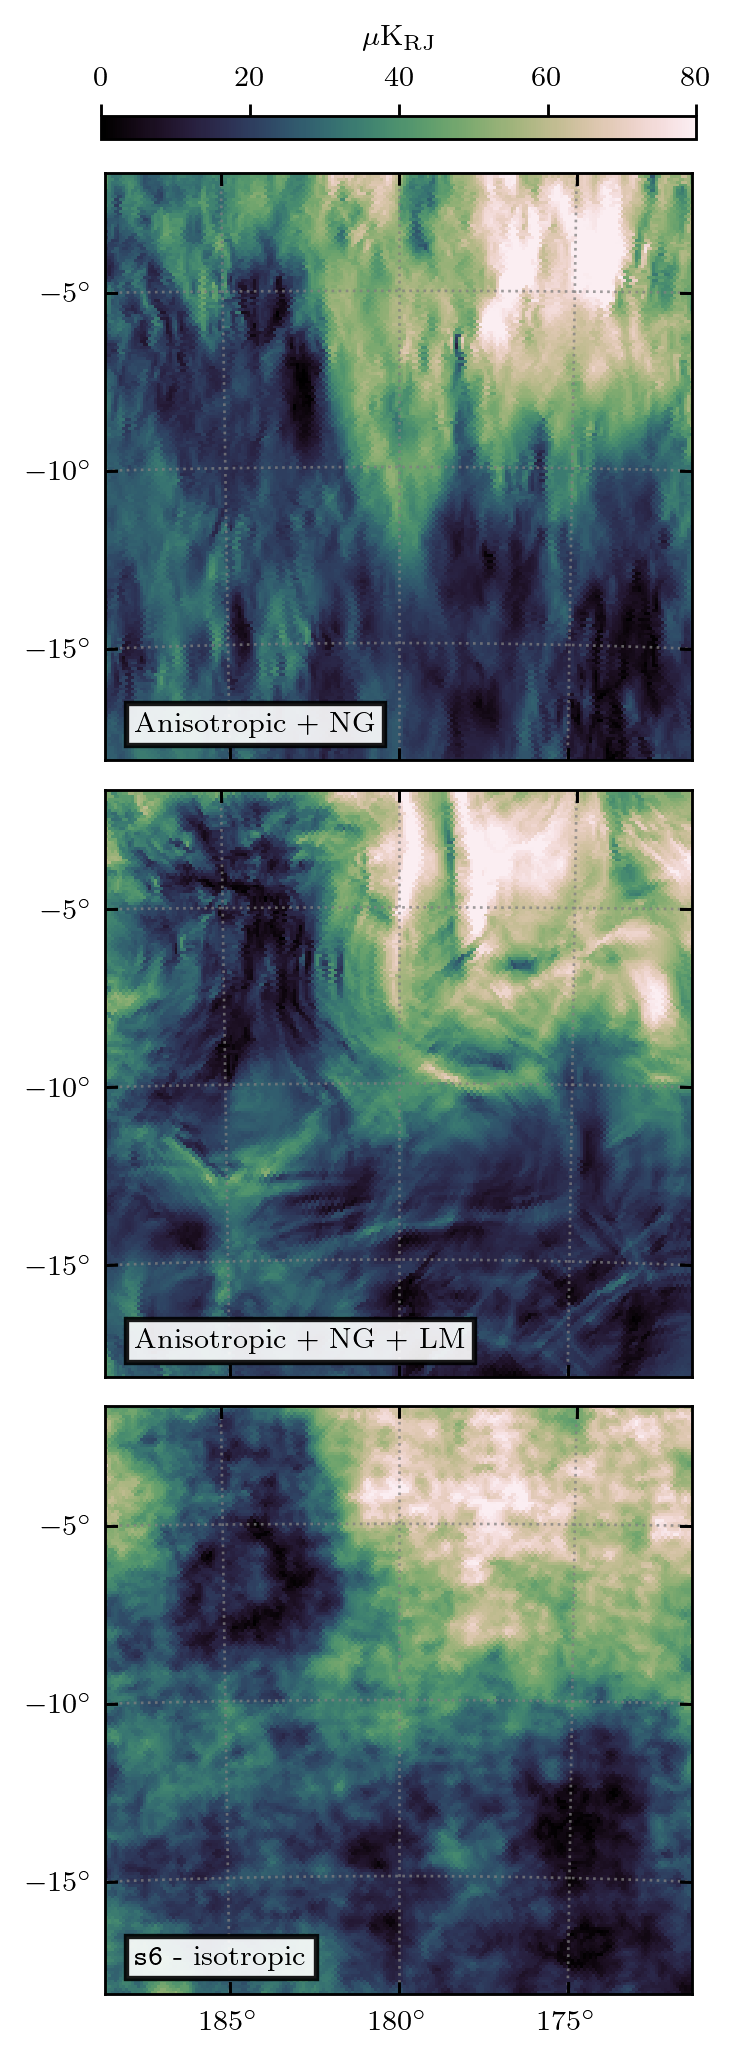

In [20]:
from astropy.wcs import WCS

# 1. Define the parameters from your get_patch_data extraction
# Assuming these variables exist in your script:
# l_center, b_center, res_arcmin
xsize = img_low1.shape[-1] # The pixel width/height of the patches

# 2. Construct the World Coordinate System (WCS) for a Gnomonic (TAN) projection
w = WCS(naxis=2)
w.wcs.crpix = [xsize / 2.0 + 0.5, xsize / 2.0 + 0.5]  # Center pixel of the image
w.wcs.crval = [180.0, -10.0]                    # Coordinate at the center pixel

# WCS standard for resolution (CDELT): 
# Longitude conventionally decreases to the right (East is left), hence negative.
# Note: If your image appears upside down due to hp.gnomview's array ordering, 
# you may need to flip the sign of the latitude CDELT or change origin='upper'.
w.wcs.cdelt = np.array([-4.94 / 60.0, 4.94 / 60.0])
w.wcs.ctype = ["GLON-TAN", "GLAT-TAN"] # Galactic Longitude/Latitude, Tangent (Gnomonic) projection

# 3. Create figure and grid with the WCS projection
fig = plt.figure(figsize=(3., 3.*3.), dpi=256)

# Create axes dynamically with the WCS projection attached
# ax = [[fig.add_subplot(1, 3, i*4 + j + 1, projection=w) for j in range(4)] for i in range(4)]
ax = [fig.add_subplot(3, 1, 1, projection=w), fig.add_subplot(3, 1, 2, projection=w), fig.add_subplot(3, 1, 3, projection=w)]

pol_cmap = sns.cubehelix_palette(start=0.5, rot=-0.95, dark=0.0, light=0.95, as_cmap=True, reverse=True)
# pol_cmap.set_under('w')

for i, img in enumerate([img_low1, img_low2, img_low3]):
    im = ax[i].imshow(img, cmap=pol_cmap, origin='lower', interpolation='none', vmin=0., vmax=80.)
    ax[i].coords.grid(color='w', alpha=0.4, linestyle='dashed')
    lon = ax[i].coords[0]
    lat = ax[i].coords[1]
    if i != 2:
        # lat.set_ticklabel_visible(False)
        lon.set_ticklabel_visible(False)

for axx in ax:
    # pretty_axes(axx)
    axx.yaxis.set_ticks_position('both')
    axx.xaxis.set_ticks_position('both')
    axx.tick_params(axis='y', direction='in')
# --->    axx.tick_params(axis='y', direction='in', which='minor')
    axx.tick_params(axis='x', direction='in')
    # axx.tick_params(axis='x', direction='in', which='minor')
    axx.grid(linestyle=':', alpha=0.75, linewidth=0.75, color='gray')
    # axx.set_yticklabels([])
    # axx.set_xticklabels([])
    axx.set_xlabel('')
    axx.set_ylabel('')

ax[0].text(0.05, 0.05, r'Anisotropic + NG', transform=ax[0].transAxes, color='black', bbox=bbox_props)
ax[1].text(0.05, 0.05, r'Anisotropic + NG + LM', transform=ax[1].transAxes, color='black', bbox=bbox_props)
ax[2].text(0.05, 0.05, r'\texttt{s6} - isotropic', transform=ax[2].transAxes, color='black', bbox=bbox_props)
# ax[2].text(0.05, 0.05, r'\texttt{s8}', transform=ax[2].transAxes, color='white')

# fig.subplots_adjust(wspace=0.1)

fig.subplots_adjust(wspace=0.1, hspace=0.05, top=0.9)
# cbar_ax = fig.add_axes([0.82, 0.1525, 0.025, 0.685])
# cbar_ax = fig.add_axes([0.82, 0.1525, 0.025, 0.685])
cbar_ax = fig.add_axes([0.125, 0.915, 0.775, 0.01])
fig.colorbar(im, cax=cbar_ax, orientation='horizontal')
cbar_ax.xaxis.set_ticks_position('top')
cbar_ax.set_title('$\mu \mathrm{K}_\mathrm{RJ}$', fontsize=8.)

fig.savefig('plots/P_ref_subfield1.pdf', pad_inches=0.1, bbox_inches='tight')


14.506666666666666 deg


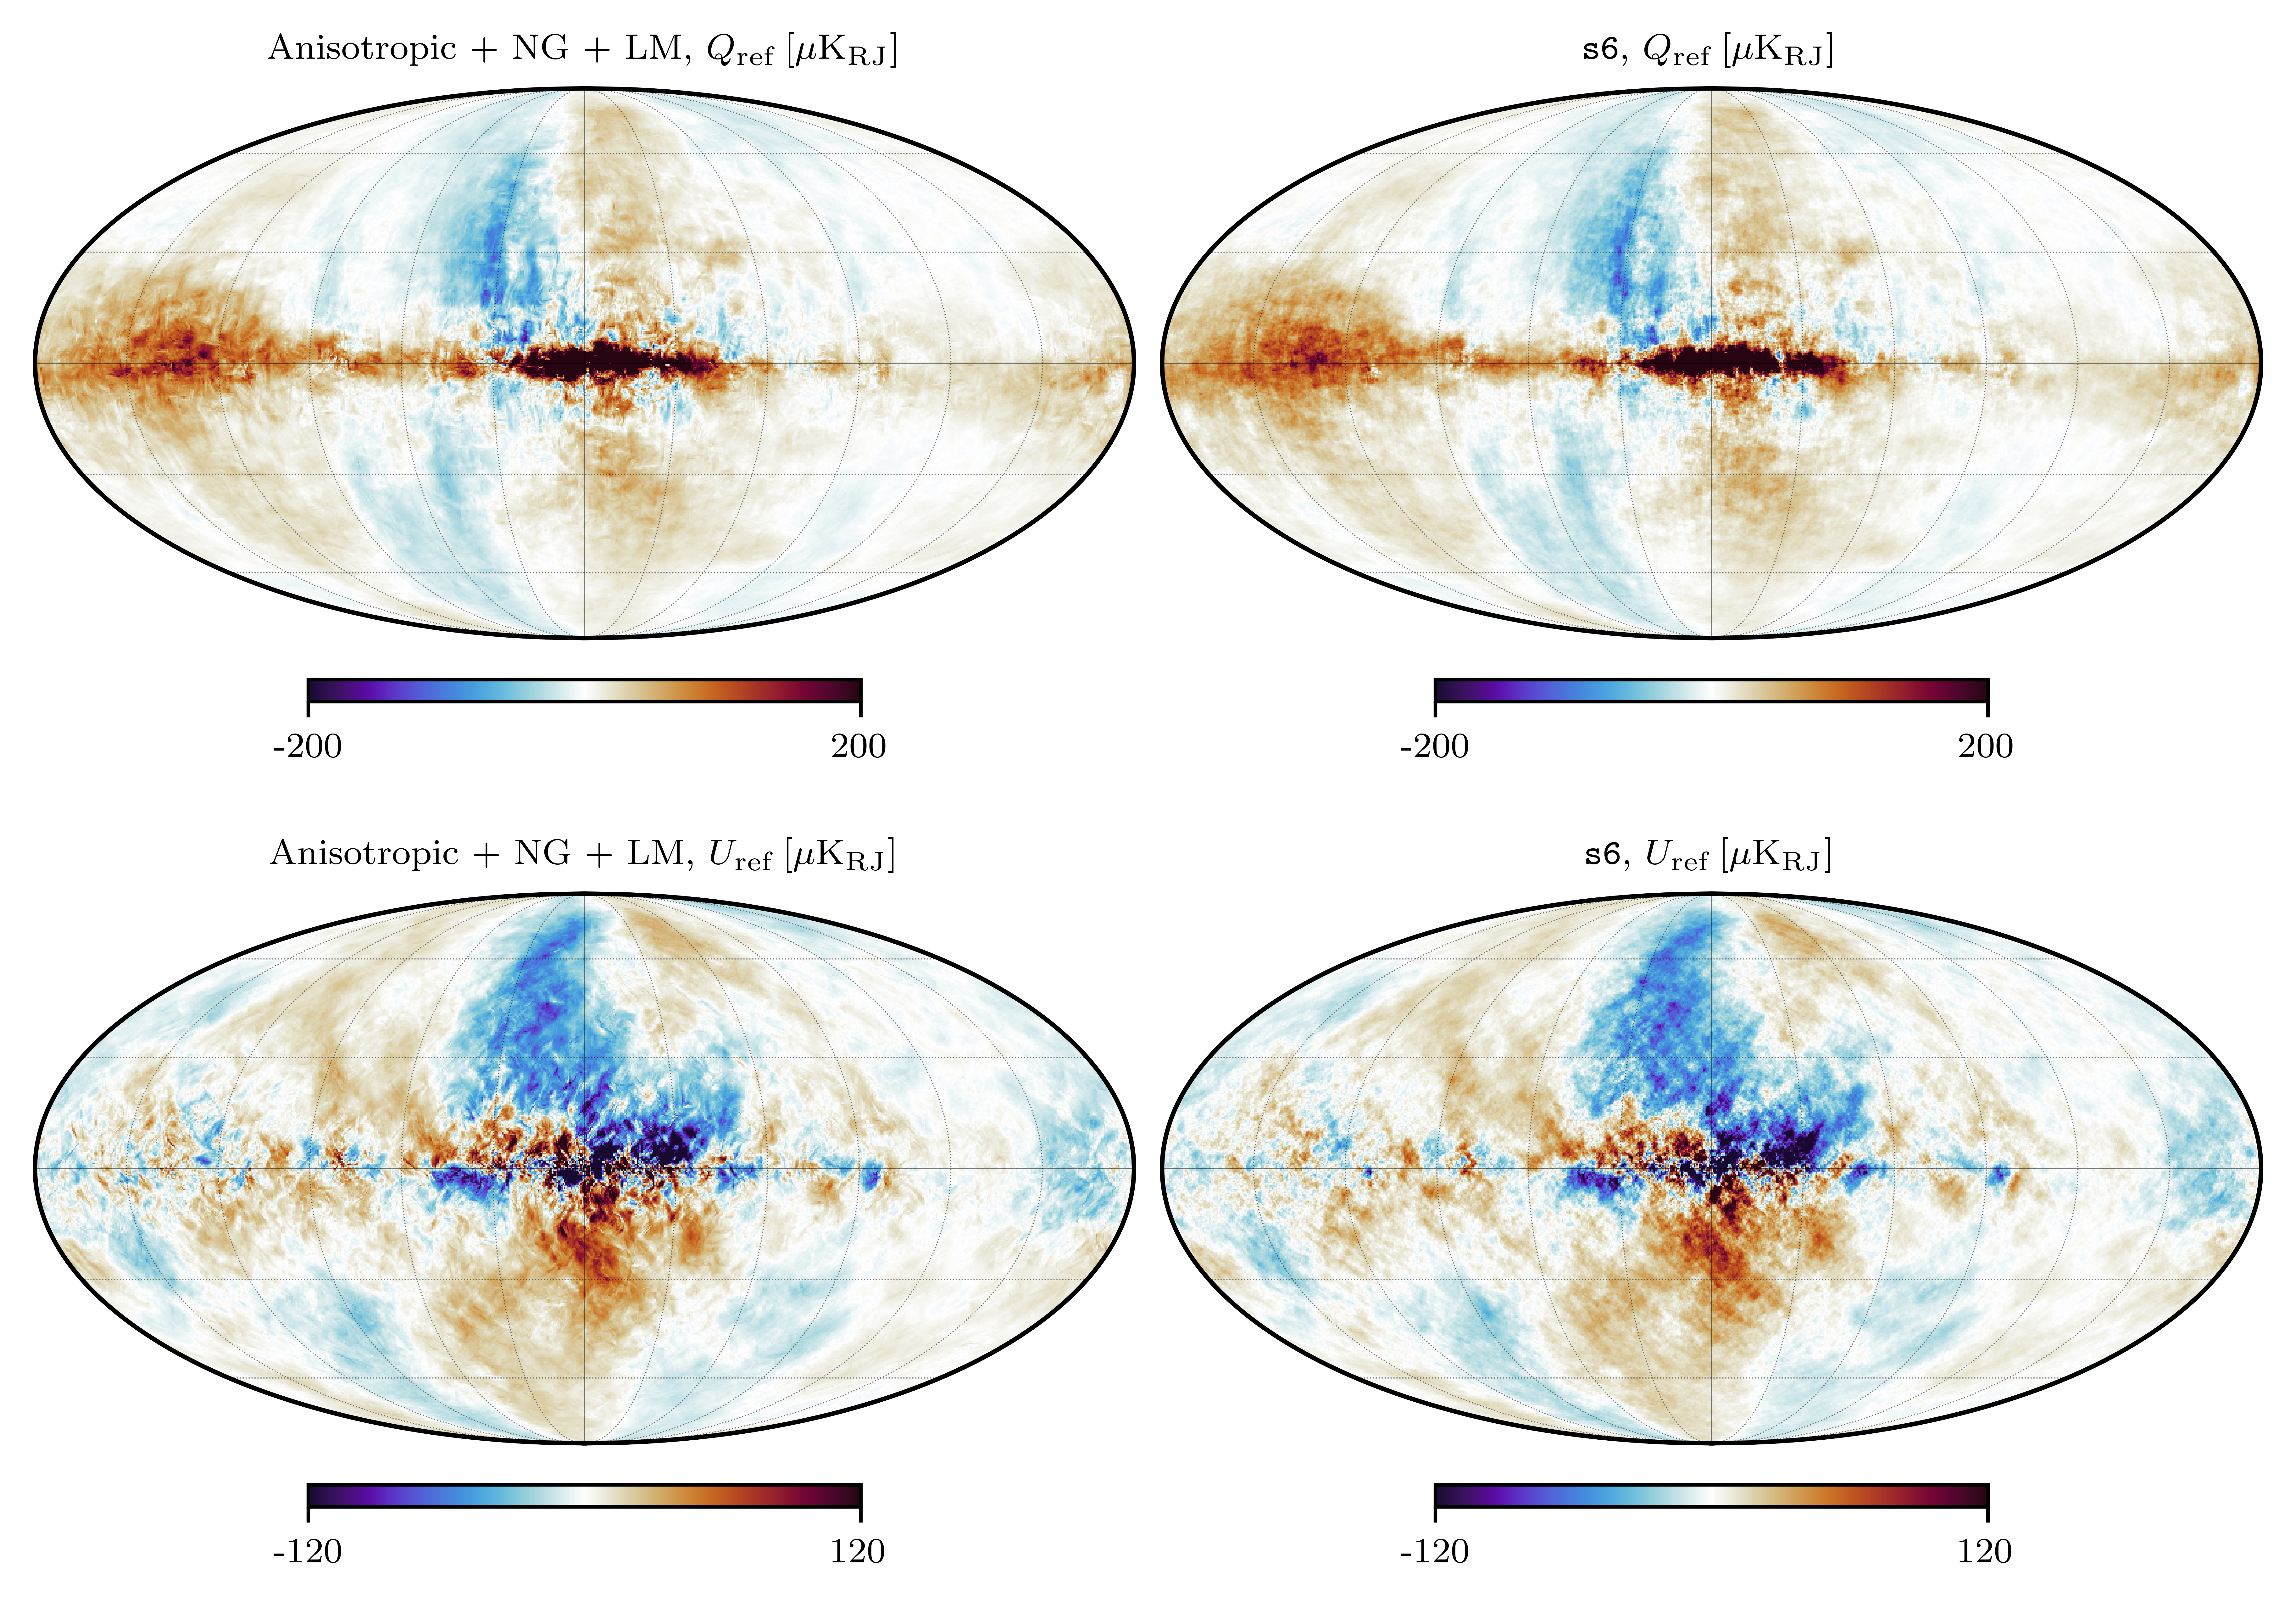

In [18]:
from src import utils
utils.modify_rc()
utils.modify_rc()

lon1 = 0.
lat1 = 0.
NPIX = 1024
DELTA_PIX = 1.7/120.
import astropy.units as u
print(((DELTA_PIX*u.deg).to(u.arcmin)*NPIX).to(u.deg))
w = utils.w_object(NPIX, DELTA_PIX, lon1, lat1)
(w, patch) = utils.patch_creation(NPIX, DELTA_PIX, lon1, lat1)

fig = plt.figure(figsize=(3.5*2., 2.5*2.), dpi=1024)

# cminE, cmaxE = utils.get_minmax([E_ref, E_sky], p=0.6)
cminE, cmaxE = -200., 200.
# cminB, cmaxB = utils.get_minmax([B_ref, B_sky], p=0.4)
cminB, cmaxB = -120., 120.

cmap2 = cmr.fusion_r
cmap2.set_under('w')
cmap2.set_over(cmap2(1.0))
cmap2.set_bad('gray')

hp.mollview(Q_ref, cmap=cmap2, title=r'', fig=fig, sub=(2, 2, 1), min=cminE, max=cmaxE, bgcolor='white')
ax = plt.gca()
ax.set_title(r'Anisotropic + NG + LM, $Q_\mathrm{ref}\,[\mu\mathrm{K}_\mathrm{RJ}]$', fontsize=8.)
# hp.graticule(alpha=0.5, linewidth=0.25)

hp.mollview(U_ref, cmap=cmap2, title=r'', fig=fig, sub=(2, 2, 3), min=cminB, max=cmaxB, bgcolor='white')
ax = plt.gca()
ax.set_title(r'Anisotropic + NG + LM, $U_\mathrm{ref}\,[\mu\mathrm{K}_\mathrm{RJ}]$', fontsize=8.)
# hp.graticule(alpha=0.5, linewidth=0.25)

hp.mollview(Q_ref_sky, cmap=cmap2, title=r'', fig=fig, sub=(2, 2, 2), min=cminE, max=cmaxE, bgcolor='white')
ax = plt.gca()
ax.set_title(r'\texttt{s6}, $Q_\mathrm{ref}\,[\mu\mathrm{K}_\mathrm{RJ}]$', fontsize=8.)
# hp.graticule(alpha=0.5, linewidth=0.25)

hp.mollview(U_ref_sky, cmap=cmap2, title=r'', fig=fig, sub=(2, 2, 4), min=cminB, max=cmaxB, bgcolor='white')
ax = plt.gca()
ax.set_title(r'\texttt{s6}, $U_\mathrm{ref}\,[\mu\mathrm{K}_\mathrm{RJ}]$', fontsize=8.)
hp.graticule(alpha=0.5, lw=0.25)

fig.savefig('plots/LM_fullscale_examples.pdf', bbox_inches='tight', pad_inches=0.1)
fig.savefig('plots/LM_fullscale_examples.png', bbox_inches='tight', pad_inches=0.1)


In [13]:
cl_mask = synthesize.get_apodized_mask(mask_idx=2)

In [14]:
T_sky, E_sky, B_sky = hp.alm2map(hp.map2alm((I_ref_sky, Q_ref_sky, U_ref_sky), pol=True), nside=NSIDE, pol=False)
T_ref, E_ref, B_ref = hp.alm2map(hp.map2alm((I_ref, Q_ref, U_ref), pol=True), nside=NSIDE, pol=False)

<>:41: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:41: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
/tmp/ipykernel_66791/4121896318.py:41: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  ax[1][0].set_ylabel('Masked, $f_\mathrm{sky}=60\%$')


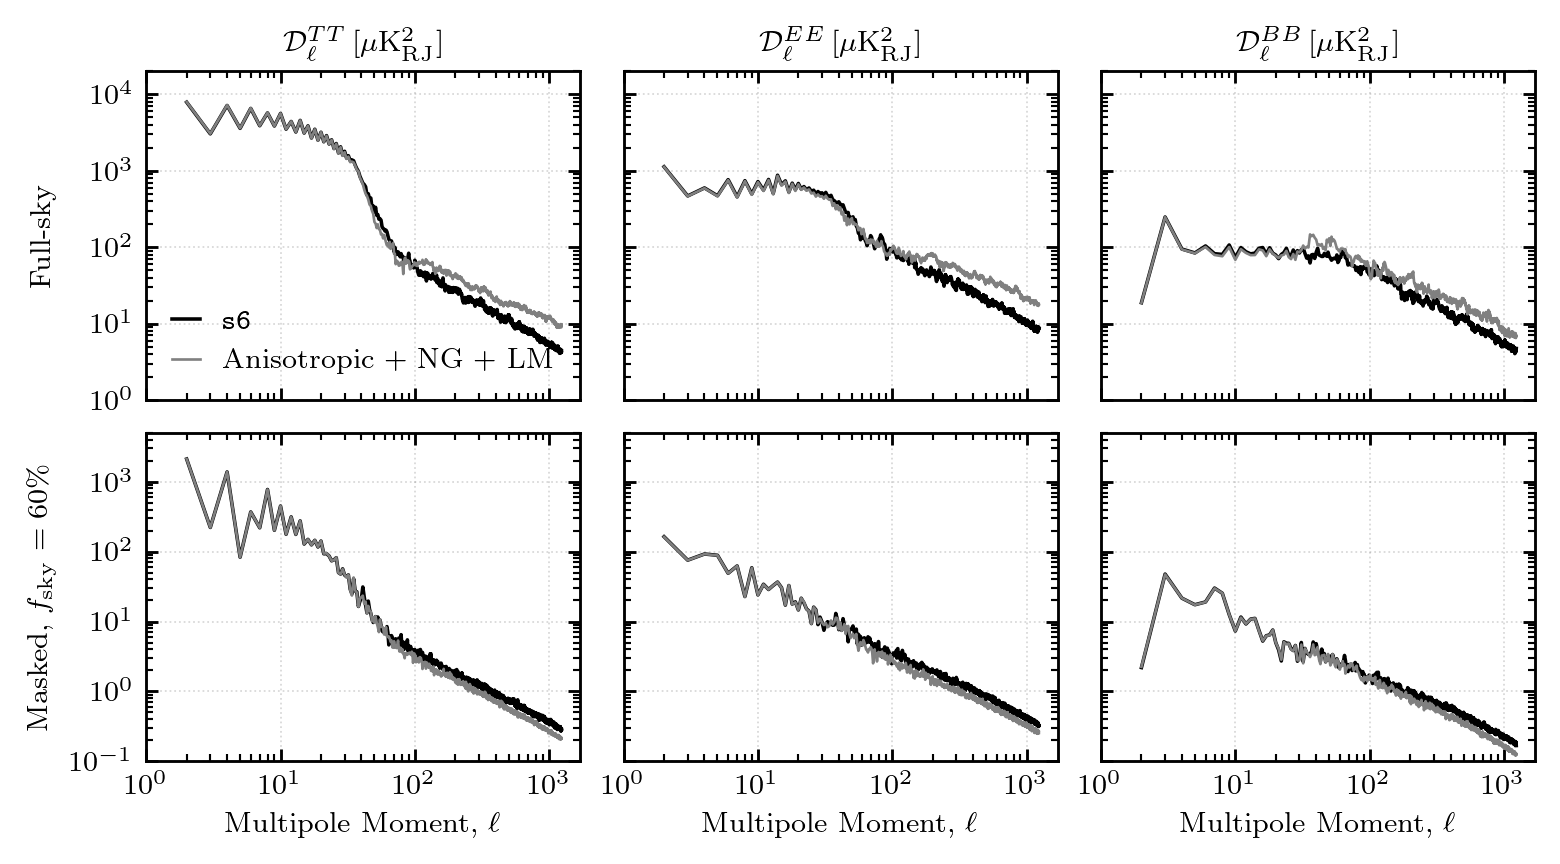

In [19]:
fig, ax = plt.subplots(2, 3, figsize=(7., 1.75*2.), dpi=256)

for i, cl in enumerate(hp.anafast([sky6.components[0].I_ref.value, sky6.components[0].Q_ref.value, sky6.components[0].U_ref.value], pol=True)):
    if i > 2:
        continue
    _l = np.arange(len(cl))
    ax[0][i].plot(_l[2:-300], (_l*(_l+1.)*cl/(2.*np.pi))[2:-300], color='black', linewidth=1.0, label=r'\texttt{s6}')

# for i, cl in enumerate(hp.anafast([I_refG, Q_refG, U_refG], pol=True)):
#     if i > 2:
#         continue
#     _l = np.arange(len(cl))
#     ax[0][i].plot(_l, cl)

for i, cl in enumerate(hp.anafast([I_ref.value, Q_ref.value, U_ref.value], pol=True)):
    if i > 2:
        continue
    _l = np.arange(len(cl))
    ax[0][i].plot(_l[2:-300], (_l*(_l+1.)*cl/(2.*np.pi))[2:-300], color='gray', linewidth=0.75, label=r'Anisotropic + NG + LM')

for i, cl in enumerate([hp.anafast(T_sky*cl_mask), hp.anafast(E_sky*cl_mask), hp.anafast(B_sky*cl_mask), hp.anafast(T_sky*cl_mask, E_sky*cl_mask)]):
    if i > 2:
        continue
    _l = np.arange(len(cl))
    ax[1][i].plot(_l[2:-300], (_l*(_l+1.)*cl/(2.*np.pi))[2:-300], color='black', linewidth=1.0)

# for i, cl in enumerate([hp.anafast(T_refG*cl_mask), hp.anafast(E_refG*cl_mask), hp.anafast(B_refG*cl_mask), hp.anafast(T_refG*cl_mask, E_refG*cl_mask)]):
#     if i > 3:
#         continue
#     _l = np.arange(len(cl))
#     ax[1][i].plot(_l, cl)

for i, cl in enumerate([hp.anafast(T_ref*cl_mask), hp.anafast(E_ref*cl_mask), hp.anafast(B_ref*cl_mask), hp.anafast(T_ref*cl_mask, E_ref*cl_mask)]):
    if i > 2:
        continue
    _l = np.arange(len(cl))
    ax[1][i].plot(_l[2:-300], (_l*(_l+1.)*cl/(2.*np.pi))[2:-300], color='gray', linewidth=0.75)

ax[0][0].legend(fancybox=False, frameon=False, fontsize=8., loc='lower left', handlelength=1.)
ax[0][0].set_ylabel('Full-sky')
ax[1][0].set_ylabel('Masked, $f_\mathrm{sky}=60\%$')

for axx in ax[0]:
    pretty_axes(axx)
    axx.loglog()
    axx.set_xticklabels([])
    axx.set_ylim((1e0, 2e4))
    if axx != ax[0][0]:
        axx.set_yticklabels([])
    axx.set_xlim((1e0, axx.get_xlim()[1]))
for axx in ax[1]:
    pretty_axes(axx)
    axx.loglog()
    axx.set_xlabel(r'Multipole Moment, $\ell$')
    axx.set_ylim((1e-1, 5e3))
    if axx != ax[1][0]:
        axx.set_yticklabels([])
    axx.set_xlim((1e0, axx.get_xlim()[1]))
fig.subplots_adjust(wspace=0.1, hspace=0.1)
fig.align_ylabels()
ax[0][0].set_title(r'$\mathcal{D}_\ell^{TT}\,[\mu\mathrm{K}_\mathrm{RJ}^2]$', fontsize=8.)
ax[0][1].set_title(r'$\mathcal{D}_\ell^{EE}\,[\mu\mathrm{K}_\mathrm{RJ}^2]$', fontsize=8.)
ax[0][2].set_title(r'$\mathcal{D}_\ell^{BB}\,[\mu\mathrm{K}_\mathrm{RJ}^2]$', fontsize=8.)

fig.savefig('plots/fullsky_models_compare_spectra.pdf', pad_inches=0.1, bbox_inches='tight')
